In [9]:
import numpy as np
import pandas as pd
from sklearn import datasets, ensemble
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.utils.fixes import parse_version
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
%matplotlib inline
import matplotlib.pyplot as plt

In [3]:
df = pd.read_excel("../../data/data_Hw3_new.xlsx")
# Ensure timestamp column is datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
feature_cols = ['A0', 'A1', 'A2', 'A3', 'temperature', 'humidity']
target_col = 'O3'

In [5]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df = df.sort_values(by=["date", "hour"]).reset_index(drop=True)

In [11]:
training_days = 28
training_hours = 28*training_days
X_train = df[feature_cols][:training_hours]
y_train = df[target_col][:training_hours]
X_test = df[feature_cols][training_hours:]
y_test = df[target_col][training_hours:]


mlr_best_model_first = LinearRegression().fit(X_train, y_train)


param_grid = {'n_neighbors': list(range(1, 20))}
knr = KNeighborsRegressor(n_jobs=-1)
knn_grid_first = GridSearchCV(knr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
knn_grid_first.fit(X_train, y_train)
knn_best_model_first = knn_grid_first.best_estimator_


param_grid = {'max_depth': list(range(1, 25))}
rfr = RandomForestRegressor(n_jobs=-1, random_state=0)
rf_grid_first = GridSearchCV(rfr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
rf_grid_first.fit(X_train, y_train)
rf_best_model_first = rf_grid_first.best_estimator_


param_grid = {'max_depth': list(range(1, 15))}
gbr = ensemble.GradientBoostingRegressor(n_estimators = 500, min_samples_split = 5, learning_rate = 0.01, random_state=0)
gb_grid_first = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
gb_grid_first.fit(X_train, y_train)
gb_best_model_first = gb_grid_first.best_estimator_

In [12]:
X_train, X_test, y_train, y_test = train_test_split(df[feature_cols], df[target_col], test_size = 0.3, random_state=0)


mlr_best_model_all = LinearRegression().fit(X_train, y_train)


param_grid = {'n_neighbors': list(range(1, 20))}
knr = KNeighborsRegressor(n_jobs=-1)
knn_grid_all = GridSearchCV(knr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
knn_grid_all.fit(X_train, y_train)
knn_best_model_all = knn_grid_all.best_estimator_


param_grid = {'max_depth': list(range(1, 25))}
rfr = RandomForestRegressor(n_jobs=-1, random_state=0)
rf_grid_all = GridSearchCV(rfr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
rf_grid_all.fit(X_train, y_train)
rf_best_model_all = rf_grid_all.best_estimator_


param_grid = {'max_depth': list(range(1, 15))}
gbr = ensemble.GradientBoostingRegressor(n_estimators = 500, min_samples_split = 5, learning_rate = 0.01, random_state=0)
gb_grid_all = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1, return_train_score=True)
gb_grid_all.fit(X_train, y_train)
gb_best_model_all = gb_grid_all.best_estimator_

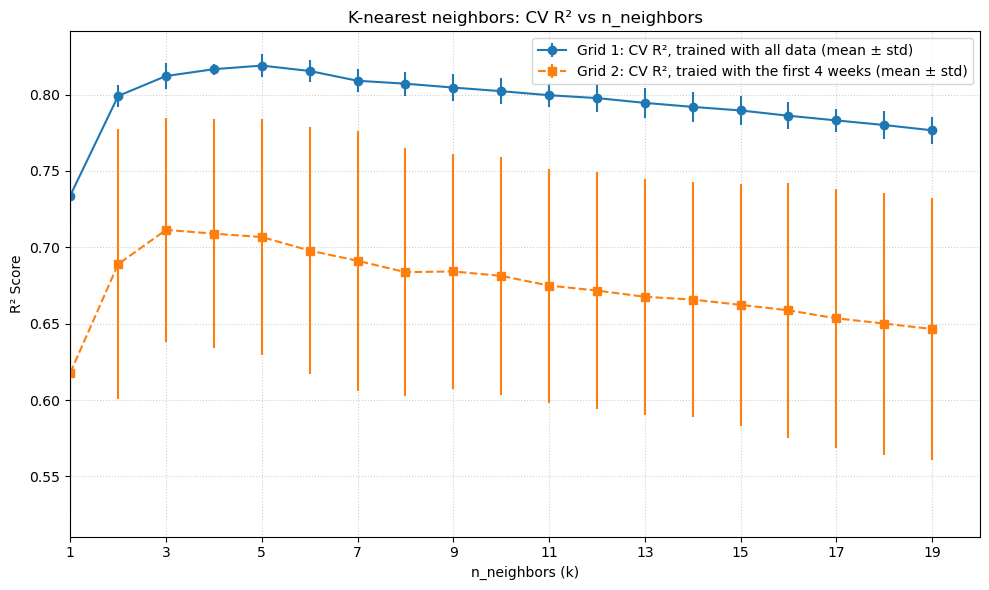

In [15]:
cv1 = knn_grid_all.cv_results_
cv2 = knn_grid_first.cv_results_

# Extract values for grid 1
k_vals1 = np.array([int(k) for k in cv1['param_n_neighbors']])
mean_test1 = cv1['mean_test_score']
std_test1  = cv1['std_test_score']

# Extract values for grid 2
k_vals2 = np.array([int(k) for k in cv2['param_n_neighbors']])
mean_test2 = cv2['mean_test_score']
std_test2  = cv2['std_test_score']

plt.figure(figsize=(10,6))

# Grid 1
plt.errorbar(
    k_vals1, mean_test1, yerr=std_test1,
    fmt='o-', label='Grid 1: CV R², trained with all data (mean ± std)'
)

# Grid 2
plt.errorbar(
    k_vals2, mean_test2, yerr=std_test2,
    fmt='s--', label='Grid 2: CV R², traied with the first 4 weeks (mean ± std)'
)

plt.title("K-nearest neighbors: CV R² vs n_neighbors")
plt.xlabel("n_neighbors (k)")
plt.ylabel("R² Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(np.arange(1, 21, 2))
plt.xlim(1, 20)
plt.legend()
plt.tight_layout()
plt.savefig("images/KNR_R2_graph.png", dpi=300)
plt.show()

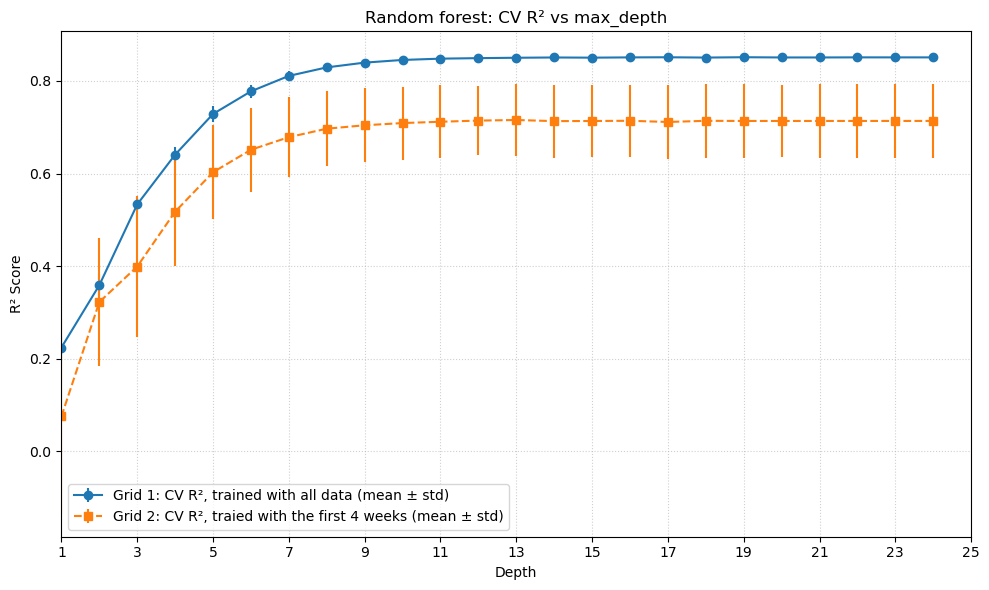

In [21]:
cv1 = rf_grid_all.cv_results_
cv2 = rf_grid_first.cv_results_

# Extract values for grid 1
k_vals1 = np.array([int(k) for k in cv1['param_max_depth']])
mean_test1 = cv1['mean_test_score']
std_test1  = cv1['std_test_score']

# Extract values for grid 2
k_vals2 = np.array([int(k) for k in cv2['param_max_depth']])
mean_test2 = cv2['mean_test_score']
std_test2  = cv2['std_test_score']

plt.figure(figsize=(10,6))

# Grid 1
plt.errorbar(
    k_vals1, mean_test1, yerr=std_test1,
    fmt='o-', label='Grid 1: CV R², trained with all data (mean ± std)'
)

# Grid 2
plt.errorbar(
    k_vals2, mean_test2, yerr=std_test2,
    fmt='s--', label='Grid 2: CV R², traied with the first 4 weeks (mean ± std)'
)

plt.title("Random forest: CV R² vs max_depth")
plt.xlabel("Depth")
plt.ylabel("R² Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(np.arange(1, 26, 2))
plt.xlim(1, 25)
plt.legend()
plt.tight_layout()
plt.savefig("images/RFR_R2_graph.png", dpi=300)
plt.show()

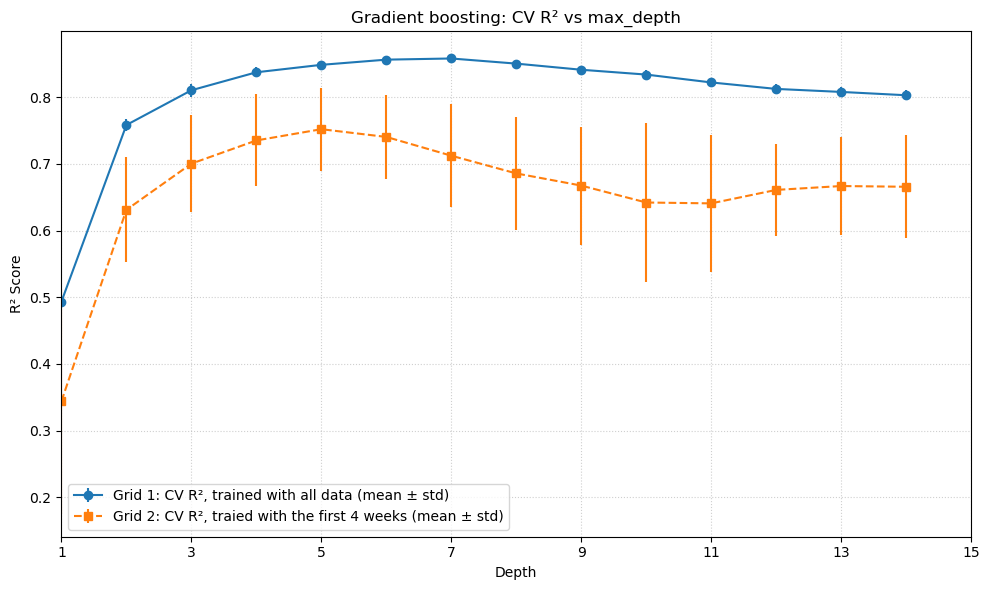

In [22]:
cv1 = gb_grid_all.cv_results_
cv2 = gb_grid_first.cv_results_

# Extract values for grid 1
k_vals1 = np.array([int(k) for k in cv1['param_max_depth']])
mean_test1 = cv1['mean_test_score']
std_test1  = cv1['std_test_score']

# Extract values for grid 2
k_vals2 = np.array([int(k) for k in cv2['param_max_depth']])
mean_test2 = cv2['mean_test_score']
std_test2  = cv2['std_test_score']

plt.figure(figsize=(10,6))

# Grid 1
plt.errorbar(
    k_vals1, mean_test1, yerr=std_test1,
    fmt='o-', label='Grid 1: CV R², trained with all data (mean ± std)'
)

# Grid 2
plt.errorbar(
    k_vals2, mean_test2, yerr=std_test2,
    fmt='s--', label='Grid 2: CV R², traied with the first 4 weeks (mean ± std)'
)

plt.title("Gradient boosting: CV R² vs max_depth")
plt.xlabel("Depth")
plt.ylabel("R² Score")
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(np.arange(1, 16, 2))
plt.xlim(1, 15)
plt.legend()
plt.tight_layout()
plt.savefig("images/GB_R2_graph.png", dpi=300)
plt.show()

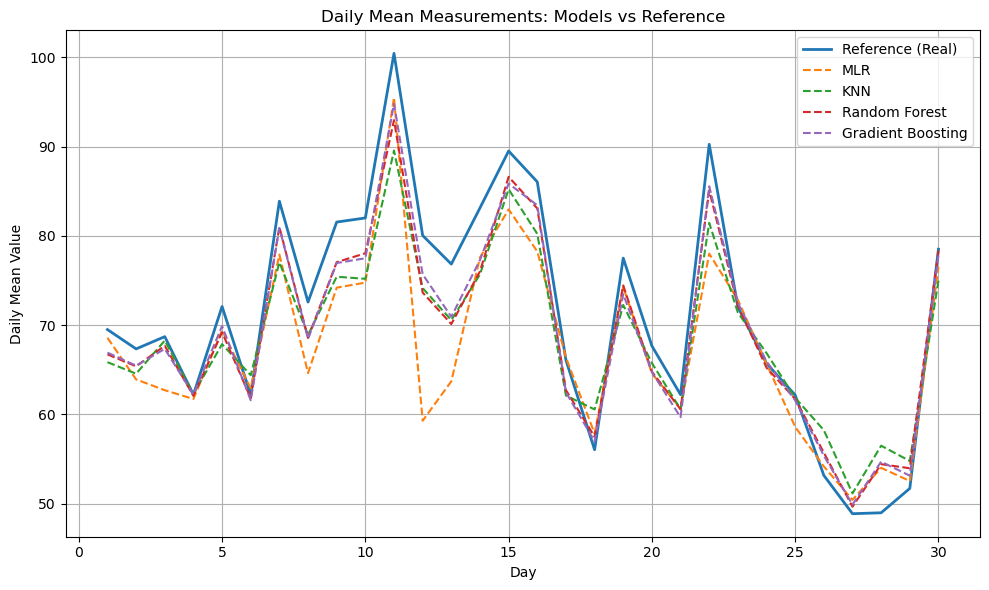

In [30]:
y_predicted_reg = mlr_best_model_all.predict(df[feature_cols])
y_predicted_KNR = knn_best_model_all.predict(df[feature_cols])
y_predicted_RF = rf_best_model_all.predict(df[feature_cols])
y_predicted_GB = gb_best_model_all.predict(df[feature_cols])
y = df[target_col]


measure_MLR = []
measure_KNN = []
measure_RF = []
measure_GB = []
real = []
first_day = 0
last_day = 24
for i in range (30):
    measure_MLR.append(np.mean(y_predicted_reg[first_day:last_day]))
    measure_KNN.append(np.mean(y_predicted_KNR[first_day:last_day]))
    measure_RF.append(np.mean(y_predicted_RF[first_day:last_day]))
    measure_GB.append(np.mean(y_predicted_GB[first_day:last_day]))
    real.append(np.mean(y[first_day:last_day]))
    first_day = first_day + 24
    last_day = last_day + 24

days = np.arange(1, 31)

plt.figure(figsize=(10, 6))

plt.plot(days, real, label='Reference (Real)', linewidth=2)
plt.plot(days, measure_MLR, label='MLR', linestyle='--')
plt.plot(days, measure_KNN, label='KNN', linestyle='--')
plt.plot(days, measure_RF, label='Random Forest', linestyle='--')
plt.plot(days, measure_GB, label='Gradient Boosting', linestyle='--')

plt.xlabel('Day')
plt.ylabel('Daily Mean Value')
plt.title('Daily Mean Measurements: Models vs Reference')
plt.legend()
plt.grid(True)
plt.savefig("images/Daily_measures_graph.png", dpi=300)
plt.tight_layout()
plt.show()

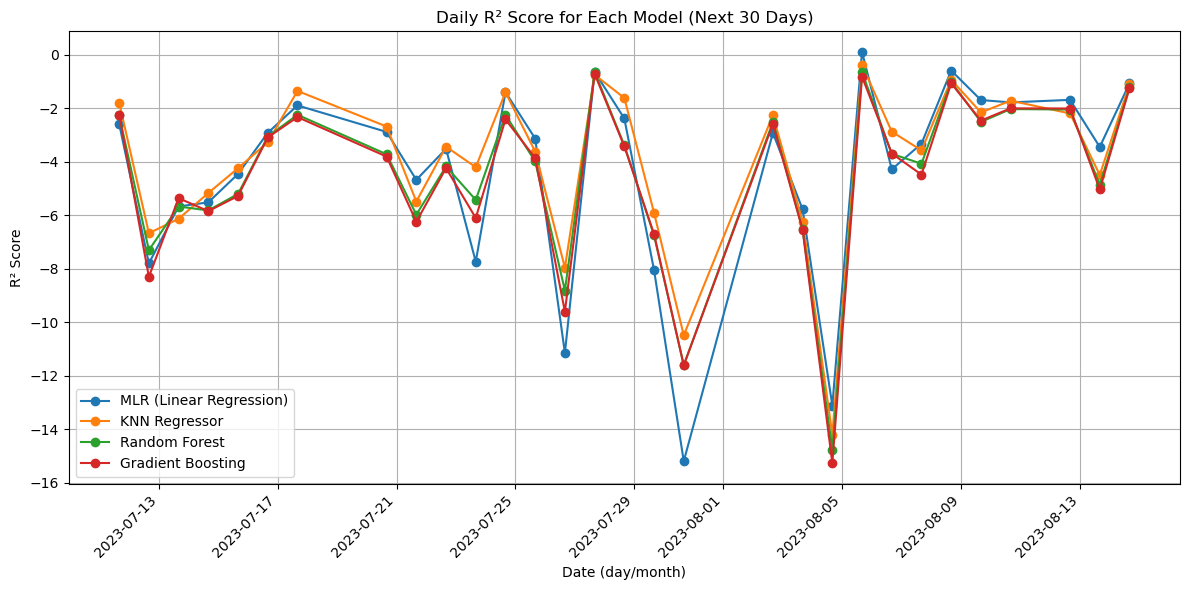

In [37]:
training_days = 28
training_hours = 28*training_days
X_train = df[feature_cols][:training_hours]
y_train = df[target_col][:training_hours]
X_test = df[feature_cols][training_hours:]
y_test = df[target_col][training_hours:]

r2_MLR = []
r2_KNN = []
r2_RF = []
r2_GB = []
first_day = 0
last_day = 24
for i in range (30):
    r2_MLR.append(r2_score(y_test[first_day:last_day], y_predicted_reg[first_day:last_day]))
    r2_KNN.append(r2_score(y_test[first_day:last_day], y_predicted_KNR[first_day:last_day]))
    r2_RF.append(r2_score(y_test[first_day:last_day], y_predicted_RF[first_day:last_day]))
    r2_GB.append(r2_score(y_test[first_day:last_day], y_predicted_GB[first_day:last_day]))
    first_day = first_day + 24
    last_day = last_day + 24

# indices of the start of each test day (24 points per day)
test_day_indices = training_hours + np.arange(len(r2_MLR)) * 24
dates = df.iloc[:,0]

selected = dates.iloc[test_day_indices]   # slice of your original 'dates' Series

# --- Robust conversion: prefer explicit format to avoid the warning ---
fmt = "%m/%d/%y %H:%M"   # match the format you passed when reading the CSV
try:
    # If values are strings in that exact format this will be fast and silent
    x_dates = pd.to_datetime(selected.values, format=fmt)
except (ValueError, TypeError):
    # fallback: try to coerce mixed formats, but this may produce NaT for bad entries
    x_dates = pd.to_datetime(selected.values, infer_datetime_format=True, errors='coerce')

# check for failed parses
if pd.isna(x_dates).any():
    bad_idx = np.where(pd.isna(x_dates))[0]
    print(f"Warning: {len(bad_idx)} date(s) failed to parse. Example index(es): {bad_idx[:5]}")
    print("Example raw values:", selected.iloc[bad_idx[:5]].tolist())

# now plotting with datetime x-axis
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(x_dates, r2_MLR, marker='o', label='MLR (Linear Regression)')
ax.plot(x_dates, r2_KNN, marker='o', label='KNN Regressor')
ax.plot(x_dates, r2_RF, marker='o', label='Random Forest')
ax.plot(x_dates, r2_GB, marker='o', label='Gradient Boosting')

ax.set_xlabel('Date (day/month)')
ax.set_ylabel('R² Score')
ax.set_title('Daily R² Score for Each Model (Next 30 Days)')
ax.grid(True)
ax.legend()


fig.autofmt_xdate(rotation=45, ha='right')  # nice label rotation
plt.tight_layout()
plt.savefig("images/Daily_graph.png", dpi=300)
plt.show()